# Banknote dimensions

Which banknotes exhibit the greatest size differences between denominations? Which are the largest overall?

Banknote dimensions differ widely across countries.

The size of a banknote impacts its practicality. Uniform dimensions enhance durability by ensuring a snug wallet fit, while also enabling vending machines and ATMs to process them seamlessly. Conversely, varied sizes assist the visually impaired in distinguishing denominations, though smaller notes can pose challenges for machine sorting and counting.

Striking a balance between these considerations is essential in currency design.

The file `banknote-dimensions.csv` shows the `length` and `width` in millimeters for 42 currencies. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'banknote-dimensions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('banknote-dimensions.csv')
df

,currency,code,value,length,width
0,Argentine Peso,ARS,2,155.0,65.0
1,Argentine Peso,ARS,5,155.0,65.0
2,Argentine Peso,ARS,10,155.0,65.0
3,Argentine Peso,ARS,20,155.0,65.0
4,Argentine Peso,ARS,50,155.0,65.0
...,...,...,...,...,...
245,West African Franc,XOF,500,114.0,60.0
246,West African Franc,XOF,1000,125.0,66.0
247,West African Franc,XOF,2000,130.0,65.0
248,West African Franc,XOF,5000,140.0,74.0


In [3]:
# longest and shortest banknotes for each currency
# modify the code below if you are more interested in width
length = df.groupby('currency').agg(max=('length', 'max'), min=('length', 'min')).reset_index()
length['diff'] = length['max'] - length['min']
length.head()

,currency,max,min,diff
0,Argentine Peso,155.0,155.0,0.0
1,Australian Dollar,158.0,130.0,28.0
2,Bangladeshi Taka,155.0,100.0,55.0
3,Bolivian Boliviano,140.0,140.0,0.0
4,Canadian Dollar,152.4,152.4,0.0


In [4]:
# helper function, change gap, vertical alignment, horizontal alignment, placement of gap...
def add_labels(df, x_col, y_col, label_col):
	for i, row in df.iterrows():
		x = row[x_col]
		y = row[y_col]
		gap = "  "
		label = gap + row[label_col]
		plt.text(x, y, label, va='center', ha='left')

### Project Ideas

- Generate paired scatter plots to compare the `length` of the longest and shortest banknotes for each currency.

- Create similar paired scatter plots, but for `width` instead of `length`.

- Incorporate the Pro Tips into your visualizations.

- Add labels to data points to highlight key insights or narrate a compelling story.

- Calculate the percentage of currencies where:
	- Only the `length` remains consistent across all denominations.
	- Only the `width` remains consistent across all denominations.
	- Both `length` and `width` vary with denominations.
	- All denominations share identical `length` and `width` dimensions.

- Visualize these findings in a clear, engaging format.

Below is a preliminary paired scatter plot of banknote length to serve as a starting point.

In [6]:
# YOUR CODE HERE (add additional cells as needed)

In [7]:
# ── Compute min/max for length and width per currency ─────────────────────────
length = df.groupby('currency').agg(max=('length', 'max'), min=('length', 'min')).reset_index()
length['diff'] = length['max'] - length['min']

width = df.groupby('currency').agg(max=('width', 'max'), min=('width', 'min')).reset_index()
width['diff'] = width['max'] - width['min']

In [8]:
# ── Helper: add labels to scatter points ──────────────────────────────────────
def add_labels(df, x_col, y_col, label_col, gap="  "):
    for i, row in df.iterrows():
        x = row[x_col]
        y = row[y_col]
        label = gap + row[label_col]
        plt.text(x, y, label, va='center', ha='left', fontsize=7)

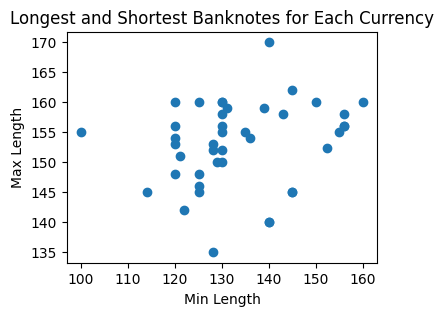

In [5]:
plt.figure(figsize=(4, 3))  
plt.scatter(length['min'], length['max'])
plt.xlabel('Min Length')
plt.ylabel('Max Length')
plt.title('Longest and Shortest Banknotes for Each Currency')
plt.show()

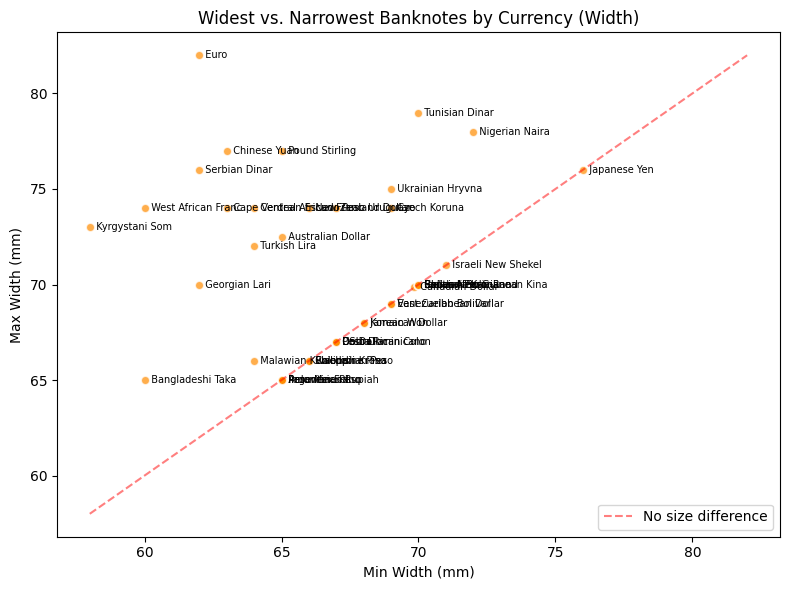

In [10]:
# ── 2. Paired scatter plot: WIDTH (min vs max) ────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(width['min'], width['max'], color='darkorange', alpha=0.7, edgecolors='white')

max_val = max(width['max'].max(), width['min'].max())
min_val = min(width['min'].min(), width['max'].min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='No size difference')

add_labels(width, 'min', 'max', 'currency')
plt.xlabel('Min Width (mm)')
plt.ylabel('Max Width (mm)')
plt.title('Widest vs. Narrowest Banknotes by Currency (Width)')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ── 3. Classify each currency by which dimensions vary ────────────────────────
def classify(row):
    length_uniform = row['length_diff'] == 0
    width_uniform  = row['width_diff'] == 0
    if length_uniform and width_uniform:
        return 'Same length & width'
    elif length_uniform:
        return 'Only length uniform'
    elif width_uniform:
        return 'Only width uniform'
    else:
        return 'Both vary'

summary = pd.DataFrame({
    'currency':    length['currency'],
    'length_diff': length['diff'],
    'width_diff':  width['diff']
})
summary['category'] = summary.apply(classify, axis=1)

# Percentage breakdown
pct = summary['category'].value_counts(normalize=True) * 100
print("Percentage of currencies in each category:\n")
print(pct.round(1).to_string())

Percentage of currencies in each category:

category
Both vary              45.2
Only width uniform     33.3
Same length & width    21.4


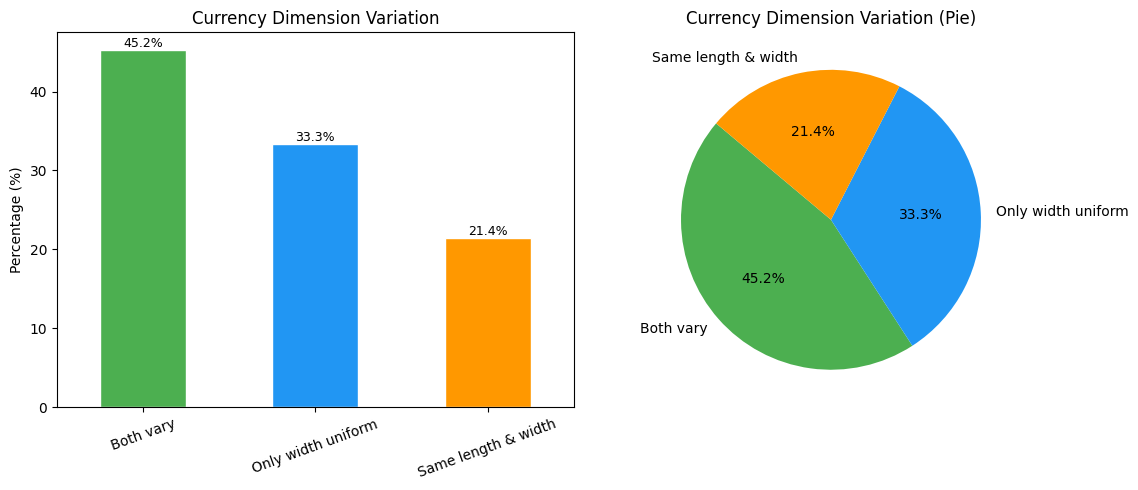

In [12]:
# ── 4. Visualise the category breakdown ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
pct.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', rot=20)
axes[0].set_title('Currency Dimension Variation')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('')
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.1f}%',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(pct, labels=pct.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Currency Dimension Variation (Pie)')

plt.tight_layout()
plt.show()

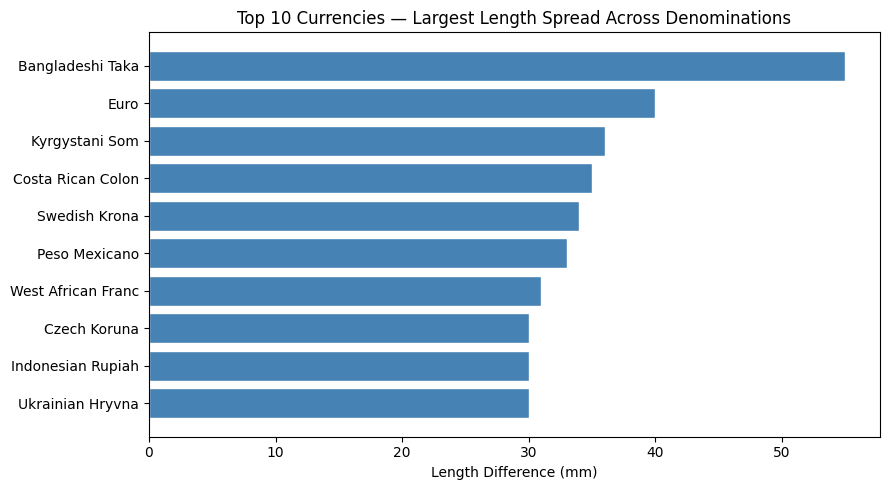

In [13]:
# ── 5. Top 10 currencies with greatest LENGTH difference ──────────────────────
top_len = length.sort_values('diff', ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(top_len['currency'], top_len['diff'], color='steelblue', edgecolor='white')
plt.xlabel('Length Difference (mm)')
plt.title('Top 10 Currencies — Largest Length Spread Across Denominations')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
